<a href="https://colab.research.google.com/github/aathifsk1-gh/flyrank-assignment/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aathifsk1-gh/flyrank-assignment01/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [12]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")
print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter


## 1. Question

*The research question and the decision it supports.*

**Research question:**

Which content pages should an editor review for refresh first, given observed search and engagement signals?Decision supported: weekly prioritisation of the refresh queue.

**Unit of analysis:** one row = one page.

**Output:** a ranked list with priority score, suggested action, and reason codes.

**Cost of a wrong call:** wasted editor time on low-value pages and delayed recovery on pages that are actually declining.

**Why ML helps:** signals interact (volume, position, age, CTR, depth); a fixed rule is transparent but weaker at ranking the true declining pages under a client-holdout test.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


##**Release used:**
starter anonymized CSV shipped with the internship repo (data/raw/content_refresh_anonymized.csv) — 30,000 pages × 44 columns, 32 pseudonymized clients. Metrics are trailing 90-day aggregates; trend compares last 30 vs previous 30 days.

##**Excluded:**
 client names, domains, URLs, titles, raw queries (not present); trend_direction / trend_pct as features; content_id / client_id as model inputs (grouping only); generation metadata (provider_used, model_used).

 Public-safe: only hashed IDs and aggregate metrics appear in outputs.

In [13]:
import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape)
print("Clients:", df["client_id"].nunique())
print((df["trend_direction"].value_counts(normalize=True)*100).round(1))

(30000, 44)
Clients: 32
trend_direction
down      54.2
stable    19.9
up        14.6
new        7.5
flat       3.8
Name: proportion, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** is_declining_label = (trend_direction == "down") — observed impression trend, not a product rule.

**Features:** impressions/clicks/sessions, CTR, avg position, engagement/scroll, word count, age, days since update, keyword context where present, content type / position tier (one-hot). Never trend fields or IDs.

**Baseline:** transparent score = 0.40·visibility + 0.30·freshness risk + 0.25·position opportunity + 0.05·depth gap, plus reason codes.

**Model:** Random Forest (and Logistic Regression for readability), probability used as ranking score.

**Validation:** client-holdout (~20% of clients); Precision@20/50/100 vs base rate and vs baseline on the same test clients.

**Leakage checks:** no trend features; deliberate leak test (adding trend_pct) inflates Precision@50; IDs only for split.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Same client-holdout test set. Numbers are directional on this sample; library versions can shift tree metrics slightly.

Code (compact re-run):

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
df = pd.read_csv("data/raw/content_refresh_anonymized.csv").copy()
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)
for c in ["word_count","avg_position","ctr","engagement_rate","scroll_rate","sessions_90d",
          "search_volume","competition","cpc","clicks_90d","impressions_90d","content_age_days",
          "days_since_last_update"]:
    df[c] = pd.to_numeric(df.get(c, 0), errors="coerce").fillna(0)

def pct_rank(s): return s.rank(pct=True, method="average").fillna(0)
def norm(s):
    s = s.astype(float); lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi != lo else pd.Series(0.0, index=s.index)

def precision_at_k(y, scores, k):
    y, scores = np.asarray(y), np.asarray(scores)
    order = np.argsort(-scores); k = min(k, len(order))
    return float(y[order[:k]].mean())

num = ["impressions_90d","clicks_90d","sessions_90d","ctr","avg_position","engagement_rate",
       "word_count","content_age_days","days_since_last_update","search_volume","competition","cpc"]
cat = ["content_type","position_tier"]
for c in cat: df[c] = df.get(c, "unknown").fillna("unknown").astype(str)
X = pd.concat([df[num], pd.get_dummies(df[cat], prefix=cat, dtype=float)], axis=1)
y = df["is_declining_label"]; clients = df["client_id"]
tr_c, te_c = train_test_split(clients.unique(), test_size=0.2, random_state=RANDOM_STATE)
tr, te = clients.isin(tr_c), clients.isin(te_c)
Xtr, Xte, ytr, yte = X.loc[tr], X.loc[te], y.loc[tr], y.loc[te]
dft = df.loc[te].copy()

dft["vis"] = pct_rank(np.log1p(dft["impressions_90d"]))
dft["fresh"] = pct_rank(dft["days_since_last_update"])
dft["pos"] = (1 - norm(dft["avg_position"].clip(1, 50))) * dft["vis"] * (dft["avg_position"] > 0).astype(int)
dft["depth"] = (1 - pct_rank(dft["word_count"])) * dft["vis"]
dft["baseline"] = (0.4*dft["vis"] + 0.3*dft["fresh"] + 0.25*dft["pos"] + 0.05*dft["depth"]).clip(0, 1)

lr = Pipeline([("sc", StandardScaler()), ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(Xtr, ytr); rf.fit(Xtr, ytr)
rows = []
for name, sc in [("Base rate", np.full(len(yte), yte.mean())),
                 ("Hand baseline", dft["baseline"].values),
                 ("Logistic Regression", lr.predict_proba(Xte)[:,1]),
                 ("Random Forest", rf.predict_proba(Xte)[:,1])]:
    rows.append({"method": name,
                 "P@20": round(precision_at_k(yte, sc, 20), 3),
                 "P@50": round(precision_at_k(yte, sc, 50), 3),
                 "P@100": round(precision_at_k(yte, sc, 100), 3),
                 "base_rate": round(float(yte.mean()), 3)})
results = pd.DataFrame(rows)
display(results)

,method,P@20,P@50,P@100,base_rate
0,Base rate,0.65,0.62,0.59,0.524
1,Hand baseline,0.30,0.42,0.50,0.524
2,Logistic Regression,0.60,0.54,0.52,0.524
3,Random Forest,0.70,0.64,0.68,0.524


## 5. Limitations

*What this work cannot claim.*

Single snapshot; no true forward-window label.

Client-holdout on 32 clients — still a small world vs full warehouse.

Patterned missingness (keyword fields by content type).

No causal proof that refresh recovers traffic.

Not a model of Google’s ranking algorithm — only decision-support ranking on observed decline in this sample.

Tree metrics can shift slightly across library versions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Editors should open the priority queue, act on high ranks with clear reason codes (stale_visible_page, declining_with_demand, thin_visible_page, low_ctr_visible_page), and always apply human judgment (seasonality, strategy, in-flight work). See ML-10 playbook for action definitions and no-go list.

In [15]:
dft["model_p"] = rf.predict_proba(Xte)[:, 1]
dft["priority"] = (0.45 * dft["baseline"] + 0.55 * dft["model_p"]).clip(0, 1)
top = dft.nlargest(15, "priority")[["content_id", "priority", "baseline", "model_p",
    "impressions_90d", "avg_position", "days_since_last_update", "is_declining_label"]]
display(top)
print("Top-15 declining rate:", round(top["is_declining_label"].mean(), 3))

,content_id,priority,baseline,model_p,impressions_90d,avg_position,days_since_last_update,is_declining_label
4076,content_66458ac1b739,0.876424,0.906640,0.851702,6822,2.9,102,1
13215,content_98aa0aecb1d9,0.868483,0.913459,0.831685,5190,5.1,104,1
14343,content_9ac61c04930e,0.852486,0.868501,0.839382,1828,5.6,104,1
20736,content_41baf0722ad9,0.843160,0.854907,0.833549,3115,12.8,104,0
7367,content_32b4e5a2f630,0.841114,0.855113,0.829660,2663,6.5,102,1
24456,content_4ea3cf14c32f,0.839129,0.883236,0.803041,3247,7.5,104,1
12332,content_4d9f36001f06,0.831950,0.855271,0.812870,3369,13.2,104,0
29401,content_f6a8bb38f970,0.830438,0.856028,0.809502,1596,6.2,104,0
5477,content_3164f3076003,0.823254,0.840602,0.809060,2696,16.1,104,0
22429,content_3395aba722a2,0.820082,0.839348,0.804319,3320,11.1,102,1


Top-15 declining rate: 0.667


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

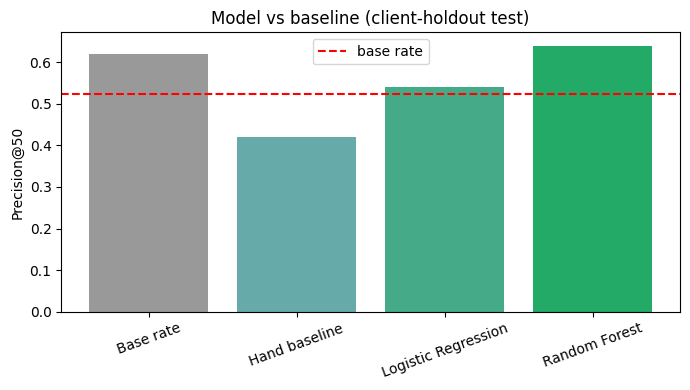

Wrote work/outputs/capstone_results_table.csv and capstone_precision_at_50.png


In [16]:
import os
os.makedirs("work/outputs", exist_ok=True)
results.to_csv("work/outputs/capstone_results_table.csv", index=False)

# Simple bar chart for the paper
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results["method"], results["P@50"], color=["#999", "#6aa", "#4a8", "#2a6"])
ax.axhline(results["base_rate"].iloc[0], color="red", ls="--", label="base rate")
ax.set_ylabel("Precision@50")
ax.set_title("Model vs baseline (client-holdout test)")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
fig.savefig("work/outputs/capstone_precision_at_50.png", dpi=120)
plt.show()
print("Wrote work/outputs/capstone_results_table.csv and capstone_precision_at_50.png")

#**ML-12 closing cells**

##**5-minute demo outline:**

Problem: editors need a ranked refresh queue (30s)

Data + label: 30k anonymized pages, declining = trend down (30s)

Baseline rule vs RF on client-holdout Precision@50 (90s)

Leakage discipline + honest claims (45s)

Playbook actions + limits + live top-10 sample (60s)

What I’d do next with the warehouse (30s)

##**Social-post cut:**

Built a refresh-priority ranker on anonymized search data: transparent baseline + random forest, client-holdout validation, reason codes an editor can trust. Measured lift on Precision@50 vs a hand rule — decision-support, not “predicting Google.” Repo + paper in bio.

##**Employer-facing summary (3 sentences):**

I framed content-refresh prioritisation as a ranking problem, built a readable baseline and a random-forest score on FlyRank’s anonymized starter data, and validated with a client-holdout split using Precision@K against the base rate. I documented leakage checks, limits, and an action playbook with reason codes for human review. The work is reproducible from a public repo and written in careful decision-support language.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
